## **Total Sales Forecasting by using Prophet**

In [2]:
# Install Prophet forecasting model
!pip install prophet pandas matplotlib scikit-learn

In [3]:
# Import the library
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [4]:
# Read the raw data from source
df = pd.read_csv(r"C:\Users\nsk_z\OneDrive\Desktop\Digitalization\9. Supply Chain Dashboard\Europe Sales Records.csv")

In [5]:
# Keep only required columns
df = df[["Order Date", "Units Sold"]]

# Convert types
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%m/%d/%Y",
    errors="coerce"
)

df["Units Sold"] = pd.to_numeric(
    df["Units Sold"],
    errors="coerce"
)

# Remove invalid rows
df = df.dropna()

# Aggregate daily sales
daily = (
    df.groupby("Order Date", as_index=False)["Units Sold"]
      .sum()
)

# Rename for Prophet
daily.columns = ["ds", "y"]

# Sort
daily = daily.sort_values("ds")

print(daily.head())

          ds      y
0 2010-01-01  17019
1 2010-01-03    313
2 2010-01-06   2979
3 2010-01-10  12378
4 2010-01-11  14755


In [6]:
# Train the model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(daily)

20:00:23 - cmdstanpy - INFO - Chain [1] start processing
20:00:24 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
# 90 days forecast of units sold
future = model.make_future_dataframe(periods=90)

forecast = model.predict(future)

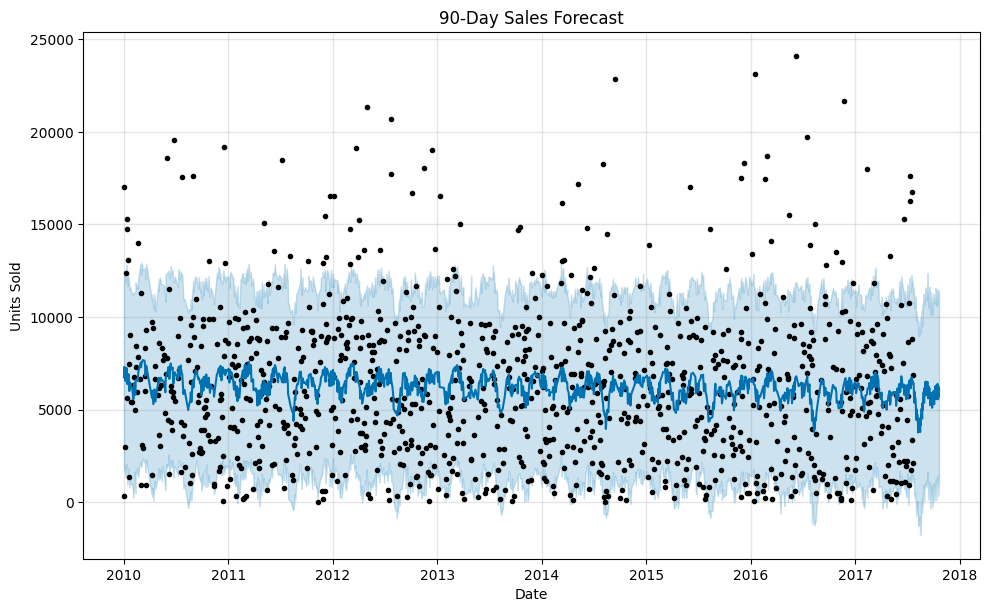

In [8]:
# Plot the forecast and actual
fig = model.plot(forecast)

plt.title("90-Day Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.show()

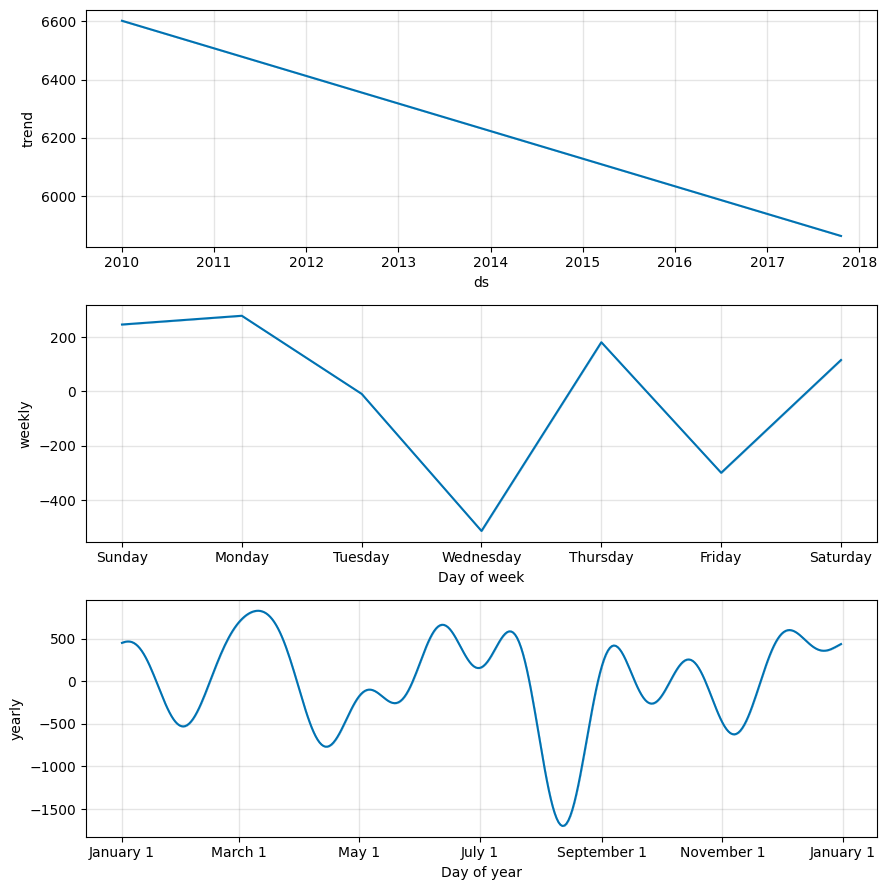

In [9]:
# Plot the seasonality 
fig2 = model.plot_components(forecast)
plt.show()

In [10]:
# Export the forecast data to csv and load into power bi for visualization
forecast_output = forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].copy()

forecast_output.columns = [
    "Forecast Date",
    "Forecast",
    "Lower Bound",
    "Upper Bound"
]

forecast_output.to_csv(
    r"C:\Users\nsk_z\OneDrive\Desktop\Digitalization\9. Supply Chain Dashboard\forecast.csv",
    index=False
)

print("Forecast saved successfully.")

Forecast saved successfully.
